# Ⅲ. 데이터와 기계학습
## 1. 데이터 속성과 유형
### 1-2 데이터 시각화

---
* **학습 목표**
  1. 데이터를 다양한 형태로 시각화할 수 있다.
  2. 데이터 시각화를 통해 데이터가 가지는 의미를 해석할 수 있다.

* **핵심 요소**
  * 데이터 시각화
  * 데이터 속성의 역할

* **핵심 질문**
  > 인공지능을 활용한 문제 해결에 필요한 데이터는 무엇일까?

## 1. 데이터를 어떻게 시각화할까?

데이터를 시각화하여 나타내는 방법은 막대, 선, 점 등 다양합니다. 수많은 데이터는 수집한 형태만으로 전체를 파악하기 어렵지만, 다양한 형태로 시각화하면 그 의미를 쉽게 파악하고 숨어 있는 정보도 쉽게 찾을 수 있습니다.

> **TIP**: 데이터 양이 많을수록 시각화를 통해 의미 있는 정보를 더 잘 파악할 수 있습니다.

---

### **(1) 막대그래프와 선 그래프**

#### **① 막대그래프 (Bar Graph)**
* **특징**: 상대적인 크기를 비교하여 알아보기에 적합합니다.
* **[교재 예시] 서울과 제주 지역의 월별 강수량 표현**
  * 서울은 8월, 제주는 9월에 비가 많이 왔음을 한눈에 비교할 수 있습니다.
  * 날씨 데이터는 기상 자료 개방 포털(http://data.kma.go.kr)에서 다운로드할 수 있습니다.

#### **② 선 그래프 (Line Graph)**
* **특징**: 데이터의 시간에 따른 변화 추이를 파악하거나 예측하고자 할 때 유용합니다.
* **[교재 예시] 코로나 확진자 수 변화**
  * 2020년 11월부터 2021년 2월까지의 데이터 표현 시, 2020년 12월에 확진자 수가 급격히 증가했음을 쉽게 알 수 있습니다.

In [4]:
import sys
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# -------------------------------
# 한글 폰트 설정
# -------------------------------

def set_korean_font():
    is_colab = "google.colab" in sys.modules

    if is_colab:
        import subprocess

        subprocess.run(
            "apt-get update -qq",
            shell=True,
            check=False
        )

        subprocess.run(
            "apt-get install -y fonts-nanum",
            shell=True,
            check=False
        )

        subprocess.run(
            "fc-cache -fv",
            shell=True,
            check=False
        )

        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        fm.fontManager.addfont(font_path)

        plt.rcParams["font.family"] = "NanumGothic"

    elif sys.platform == "darwin":
        # Mac
        plt.rcParams["font.family"] = "AppleGothic"

    elif sys.platform.startswith("win"):
        # Windows
        plt.rcParams["font.family"] = "Malgun Gothic"

    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

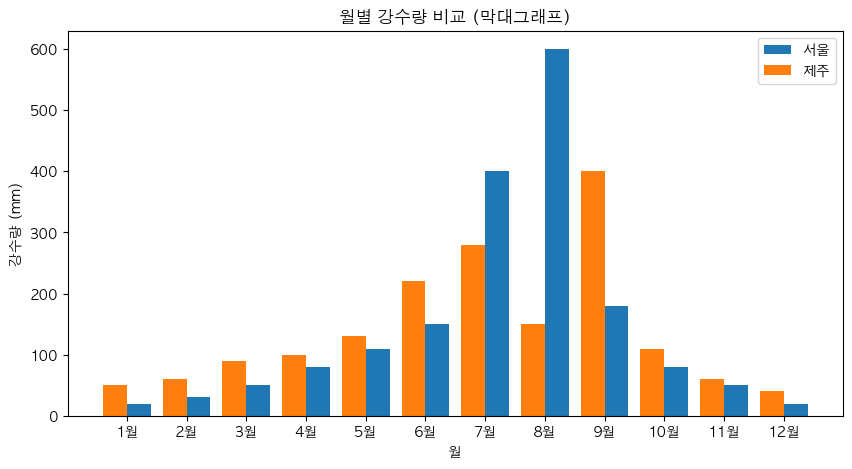

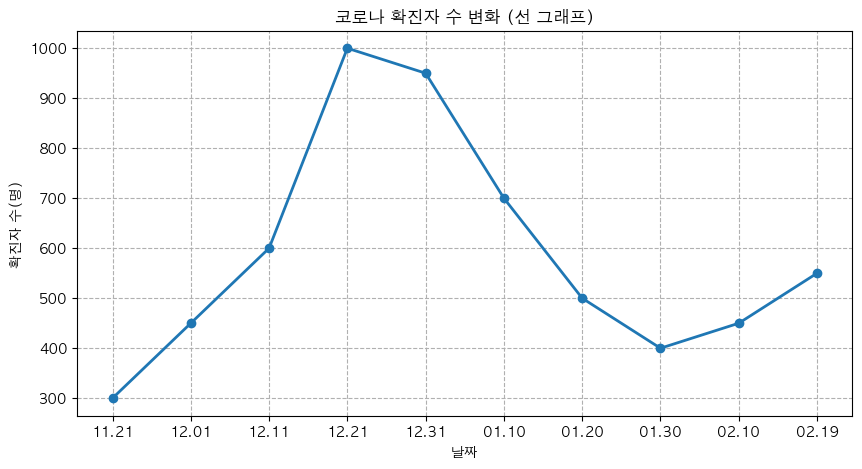

In [5]:
# [실습] 막대그래프와 선 그래프 시각화
import sys
import os
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

def set_korean_font():
    is_colab = "google.colab" in sys.modules

    if is_colab:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

        if not os.path.exists(font_path):
            subprocess.run(["apt-get", "update", "-qq"], check=False)
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], check=False)
            subprocess.run(["fc-cache", "-fv"], check=False)

        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = "NanumGothic"

    elif sys.platform == "darwin":
        plt.rcParams["font.family"] = "AppleGothic"

    elif sys.platform.startswith("win"):
        plt.rcParams["font.family"] = "Malgun Gothic"

    else:
        plt.rcParams["font.family"] = "NanumGothic"

    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

months = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
seoul_rain = [20, 30, 50, 80, 110, 150, 400, 600, 180, 80, 50, 20]
jeju_rain = [50, 60, 90, 100, 130, 220, 280, 150, 400, 110, 60, 40]

plt.figure(figsize=(10, 5))
plt.bar(months, seoul_rain, width=0.4, label='서울', align='edge')
plt.bar(months, jeju_rain, width=-0.4, label='제주', align='edge')
plt.title('월별 강수량 비교 (막대그래프)')
plt.xlabel('월')
plt.ylabel('강수량 (mm)')
plt.legend()
plt.show()

dates = ['11.21', '12.01', '12.11', '12.21', '12.31', '01.10', '01.20', '01.30', '02.10', '02.19']
cases = [300, 450, 600, 1000, 950, 700, 500, 400, 450, 550]

plt.figure(figsize=(10, 5))
plt.plot(dates, cases, marker='o', linestyle='-', linewidth=2)
plt.title('코로나 확진자 수 변화 (선 그래프)')
plt.xlabel('날짜')
plt.ylabel('확진자 수(명)')
plt.grid(True, linestyle='--')
plt.show()

### **(2) 산점도 (Scatter Plot)**

데이터 속성 간의 관계를 시각화하여 쉽게 알아볼 수 있는 대표적인 방법입니다.
* **방법**: x축과 y축 두 값이 만나는 위치에 점을 표시하여 두 축 간의 관계를 나타냅니다.
* **활용**: 기계 학습에서 **독립 변수와 종속 변수의 관계**를 파악하는 데 매우 적절합니다.

#### **[교재 예시] 과목별 성적과 등급의 상관관계**
* **국어 성적 산점도**: 점들이 일정한 방향(우하향)으로 조밀하게 모여 있어 등급 예측에 영향이 큼을 알 수 있습니다.
* **영어 성적 산점도**: 국어에 비해 점들이 조금 더 퍼져 있으며, 특히 **이상치(Outlier)**가 존재합니다.

#### **중요 개념: 이상치 (Outlier)**
* 관측된 데이터의 범위에서 많이 벗어난 아주 작은 값이나 아주 큰 값을 의미합니다.
* 영어 성적에 낮은 이상치가 포함되어 있으면 영어 성적과 전체 등급의 상관 정도가 국어 성적에 비해 낮아지게 됩니다.

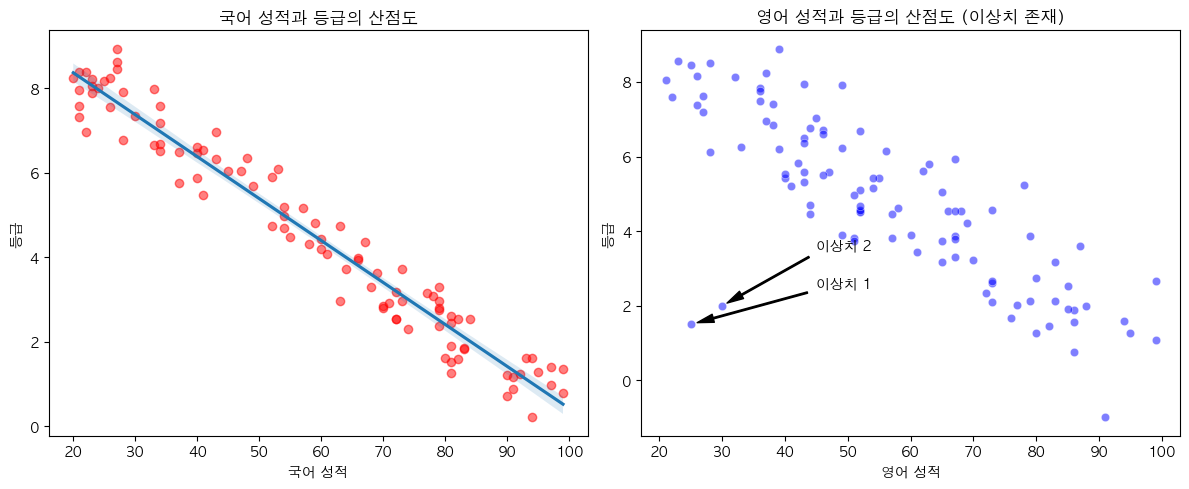

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 데이터 생성: 성적과 등급 (음의 상관관계)
np.random.seed(42)
korean_score = np.random.randint(20, 100, 100)
grades = 10 - (korean_score // 10) + np.random.normal(0, 0.5, 100)

english_score = np.random.randint(20, 100, 100)
english_grades = 10 - (english_score // 10) + np.random.normal(0, 1.0, 100)

# 실제 이상치 데이터 추가 (낮은 점수이나 높은 등급을 받은 경우)
outliers_x = np.array([25, 30])
outliers_y = np.array([1.5, 2.0])

english_score = np.append(english_score, outliers_x)
english_grades = np.append(english_grades, outliers_y)

plt.figure(figsize=(12, 5))

# 국어 성적 산점도
plt.subplot(1, 2, 1)
sns.regplot(x=korean_score, y=grades, scatter_kws={'color':'red', 'alpha':0.5})
plt.title('국어 성적과 등급의 산점도')
plt.xlabel('국어 성적')
plt.ylabel('등급')

# 영어 성적 산점도 (이상치 포함)
plt.subplot(1, 2, 2)
sns.scatterplot(x=english_score, y=english_grades, color='blue', alpha=0.5)
plt.title('영어 성적과 등급의 산점도 (이상치 존재)')
plt.xlabel('영어 성적')
plt.ylabel('등급')

# 수정된 이상치 데이터 위치에 주석 표시
plt.annotate('이상치 1', xy=(25, 1.5), xytext=(45, 2.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.annotate('이상치 2', xy=(30, 2.0), xytext=(45, 3.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.show()

### **(3) 기타: 워드 클라우드 (Word Cloud)**

* **정의**: 태그 클라우드라고도 하며, 메타 데이터에서 얻어진 태그들을 분석하여 중요도나 인기도 등을 고려하여 시각적으로 표시하는 방법입니다.
* **특징**: 보통 중요도가 높을수록 글자의 크기가 크게 배치됩니다.
* **활용**: SNS 댓글이나 긴 텍스트 데이터 속에 포함된 주요 의미를 쉽게 파악할 수 있습니다.
* **[교재 예시]**: 수능 필적 확인 문구('정지용의 향수')를 활용한 워드 클라우드 시각화.

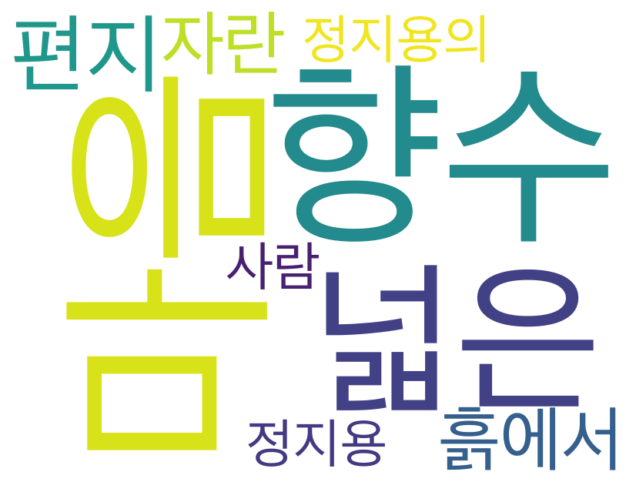

In [5]:
# [실습] 워드 클라우드 시각화
import sys
import os
import subprocess
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def get_korean_font_path():
    is_colab = "google.colab" in sys.modules

    if is_colab:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

        if not os.path.exists(font_path):
            subprocess.run(["apt-get", "update", "-qq"], check=False)
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], check=False)
            subprocess.run(["fc-cache", "-fv"], check=False)

        return font_path

    elif sys.platform == "darwin":
        mac_font_candidates = [
            "/System/Library/Fonts/AppleSDGothicNeo.ttc",
            "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
            "/Library/Fonts/NanumGothic.ttf",
        ]

        for font_path in mac_font_candidates:
            if os.path.exists(font_path):
                return font_path

    elif sys.platform.startswith("win"):
        win_font_candidates = [
            "C:/Windows/Fonts/malgun.ttf",
            "C:/Windows/Fonts/malgunbd.ttf",
        ]

        for font_path in win_font_candidates:
            if os.path.exists(font_path):
                return font_path

    raise FileNotFoundError("사용 가능한 한글 폰트를 찾지 못했습니다.")

font_path = get_korean_font_path()

text = "정지용 향수 넓은 마음 편지 흙에서 자란 마음 정지용의 향수 넓은 마음 흙에서 자란 사람 향수 마음 편지"

wordcloud = WordCloud(
    font_path=font_path,
    background_color="white",
    width=800,
    height=600
).generate(text)

plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 2. 스스로 해결하기: 구글 트렌드와 산점도 분석

구글 트렌드(https://trends.google.co.kr/)를 활용하여 특정 키워드에 대한 관심도 변화를 분석해 봅니다.

* **[실습 사례] 한라산과 설악산 관심도 비교**
  1. 검색어에 '한라산', '설악산' 입력
  2. 기간을 최근 2년(예: 2019.01 ~ 2021.02)으로 설정
  3. 데이터(.csv) 다운로드 및 분석

---

## 3. 데이터 시각화로 속성의 역할을 알 수 있을까?

데이터 시각화를 통해 기계학습에 많은 영향을 미치는 속성을 파악할 수 있습니다. 교재에서는 교육용 데이터 마이닝 도구인 **오렌지(Orange)** 프로그램을 활용하여 이를 확인하는 과정을 설명합니다.

### **오렌지(Orange) 프로그램 활용 과정 요약**
1. **File 위젯**: `Iris.csv` 데이터를 불러오고 속성(Role)을 설정합니다.
   * `feature`: 독립 변수 (꽃받침/꽃잎의 길이와 너비)
   * `target`: 종속 변수 (품종 - Species)
   * `meta`: 기계학습에 영향을 주지 않는 항목 (Id 등)
2. **Data Table 위젯**: 속성값을 표 형태로 확인합니다.
3. **Scatter Plot 위젯**: 산점도를 통해 속성 간의 관계와 품종 분류 가능성을 시각화합니다.

=== 붓꽃 데이터 속성 확인 ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


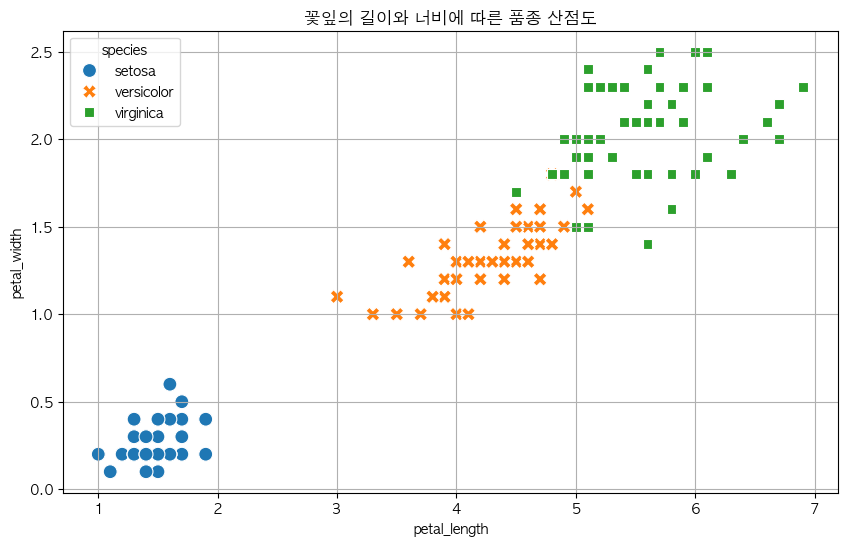

In [6]:
# [실습] 오렌지 프로그램의 과정을 파이썬 코드로 구현 (붓꽃 데이터 시각화)
import seaborn as sns

# 1. 데이터 불러오기 (Seaborn 내장 붓꽃 데이터 활용)
iris = sns.load_dataset('iris')

# 2. 데이터 속성의 역할 확인 (상위 5개 행)
print("=== 붓꽃 데이터 속성 확인 ===")
print(iris.head())

# 3. 산점도로 파악하기 (교재 그림 III-9 재구성)
# (b) 꽃잎 길이(petal_length)와 꽃잎 너비(petal_width)에 따른 품종 분포
plt.figure(figsize=(10, 6))
sns.scatterplot(x='petal_length', y='petal_width', hue='species', style='species', data=iris, s=100)
plt.title('꽃잎의 길이와 너비에 따른 품종 산점도')
plt.grid(True)
plt.show()

# 4. 결론 도출: 
# 시각화 결과, 꽃잎의 길이와 너비 속성이 품종(setosa, versicolor, virginica)을 
# 구분하는 데 매우 강력한 '독립 변수' 역할을 하고 있음을 확인할 수 있습니다.

### **(2) 특성 통계표로 파악하기 (Feature Statistics)**

특성 통계표는 값의 분포를 시각적으로 확인할 수 있도록 속성값의 점수 분포를 막대 모양의 히스토그램으로 표현합니다.

* **Distribution(분포)**: 각 품종별 속성값의 범위를 보여줍니다.
* **해석**:
  * **꽃잎 길이(PetalLength)**: 품종별로 히스토그램이 확연히 분리되어 있어 품종 구분이 쉽습니다.
  * **꽃받침 길이(SepalLength)**: 품종 간 히스토그램이 많이 겹쳐 있어 상대적으로 품종 구분에 어려움이 있습니다.

---

## 정리하기

1. **데이터 시각화의 의미 해석**: 다양한 그래프(막대, 선, 산점도 등)를 통해 데이터 속에 숨겨진 의미와 트렌드를 파악할 수 있습니다.
2. **기계학습 활용**: 데이터 시각화는 종속 변수에 영향을 주는 핵심 **독립 변수**를 추출하는 데 유용하게 활용됩니다.
3. **속성 추출**: 산점도와 특성 통계표를 분석하여 기계학습 모델의 성능에 결정적인 영향을 미치는 주요 속성을 선택할 수 있습니다.

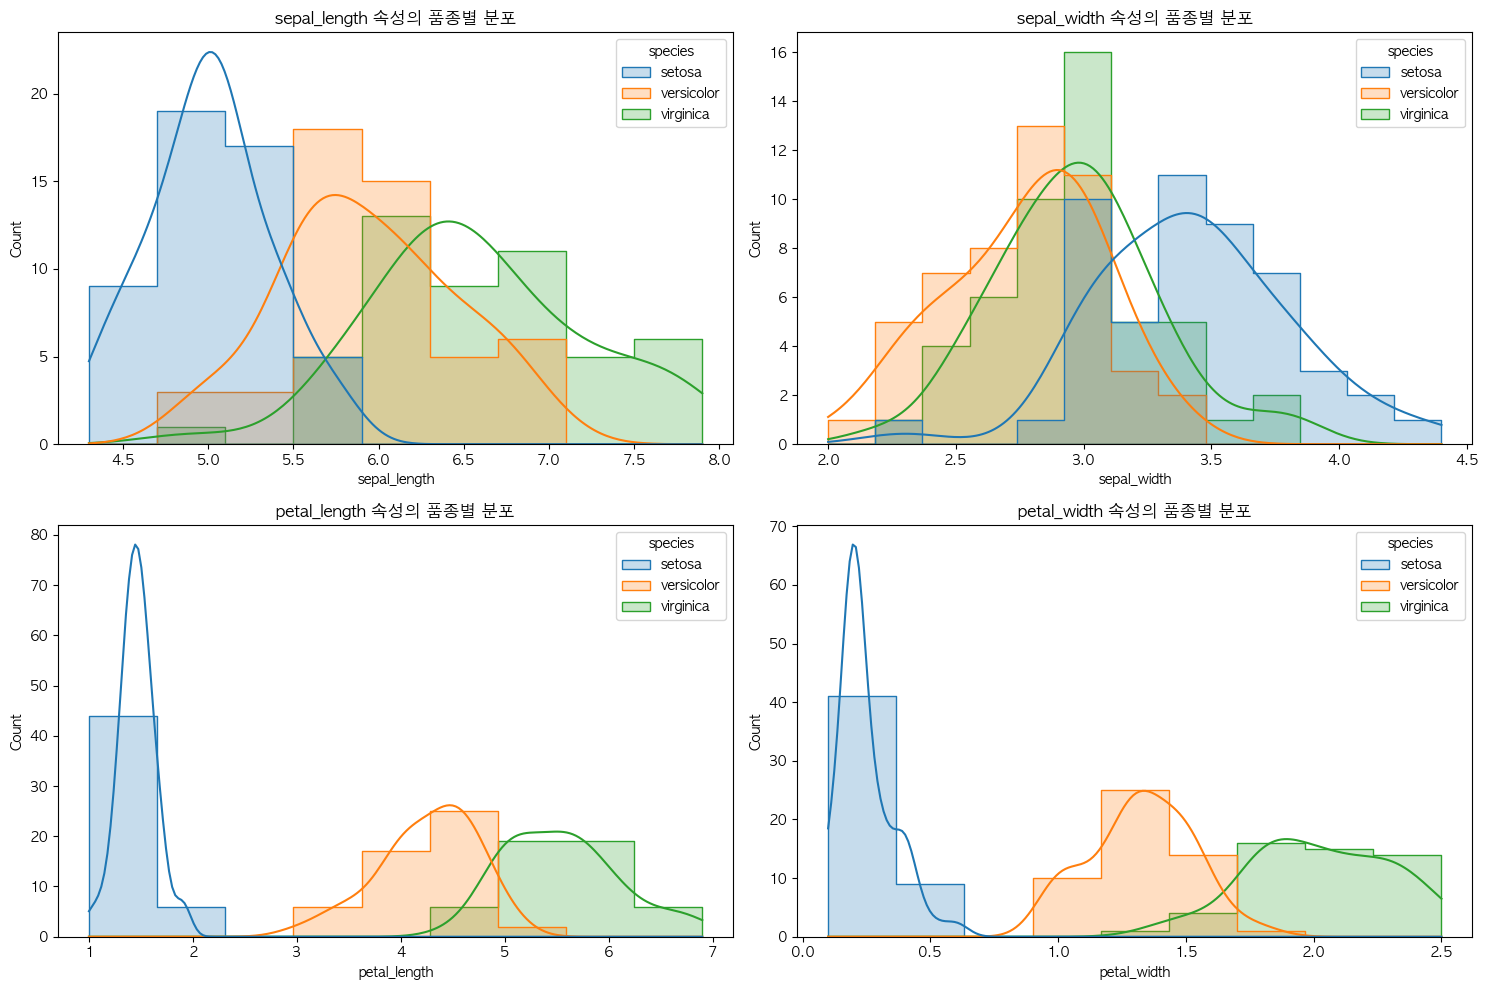

분석 결과: Petal Length와 Petal Width가 Sepal 관련 속성보다 품종을 더 명확하게 구분해줍니다.


In [7]:
# [실습] 특성 통계표(히스토그램) 시각화 (교재 그림 III-10 재구성)
plt.figure(figsize=(15, 10))

# 4개의 속성에 대한 분포 확인
features = iris.columns[:-1]
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=iris, x=col, hue='species', kde=True, element="step")
    plt.title(f'{col} 속성의 품종별 분포')

plt.tight_layout()
plt.show()

print("분석 결과: Petal Length와 Petal Width가 Sepal 관련 속성보다 품종을 더 명확하게 구분해줍니다.")

# 실습
## 실습 1. 막대그래프: 국가별 아이돌 수
## 실습 2. 막대그래프: 성별 아이돌 수
## 실습 3. 선 그래프: 데뷔 연도별 아이돌 수 변화
## 실습 4. 산점도: 키와 몸무게의 관계
## 실습 5. 히스토그램: 키 분포 확인하기
## 실습 6. 회사별 아이돌 수 비교하기
## 실습 7. 데이터 속성의 역할 생각하기

In [ ]:
country_count = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_count.plot(kind="bar")
plt.title("국가별 아이돌 수")
plt.xlabel("국가")
plt.ylabel("아이돌 수")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [ ]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(6, 5))
gender_count.plot(kind="bar")
plt.title("성별 아이돌 수")
plt.xlabel("성별")
plt.ylabel("아이돌 수")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [ ]:
debut_count = df["Debut Year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(debut_count.index, debut_count.values, marker="o")
plt.title("데뷔 연도별 아이돌 수 변화")
plt.xlabel("데뷔 연도")
plt.ylabel("아이돌 수")
plt.grid(True)
plt.show()

In [ ]:
body_df = df.dropna(subset=["Height", "Weight", "Gender"])

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=body_df,
    x="Height",
    y="Weight",
    hue="Gender",
    alpha=0.7
) 

plt.title("아이돌의 키와 몸무게 산점도")
plt.xlabel("키(cm)")
plt.ylabel("몸무게(kg)")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=body_df, x="Height", hue="Gender", bins=20, kde=True)

plt.title("성별에 따른 키 분포")
plt.xlabel("키(cm)")
plt.ylabel("아이돌 수")
plt.grid(True)
plt.show()

In [ ]:
company_count = df["Company"].value_counts().head(15)

plt.figure(figsize=(12, 5))
company_count.plot(kind="bar")
plt.title("회사별 아이돌 수 상위 15개")
plt.xlabel("회사")
plt.ylabel("아이돌 수")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

In [ ]:
selected = df[["Stage Name", "Group", "Company", "Country", "Gender", "Height", "Weight", "Debut Year"]]

selected.head(10)